<a href="https://colab.research.google.com/github/parisaGBP/MachineLearning2024/blob/main/MiniProject1/MLMiniproject1q3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##ML-Mini project1- question3


#Data

In [2]:
# https://drive.google.com/file/d/1rNpKPIIVrPCL5IRECbwahLhKWbEtjjJE/view?usp=sharing
# https://drive.google.com/file/d/1ZhEyi6kIDWrFlPXGwkgdIZJP9uoucjab/view?usp=sharing
!gdown 1ZhEyi6kIDWrFlPXGwkgdIZJP9uoucjab

Downloading...
From: https://drive.google.com/uc?id=1ZhEyi6kIDWrFlPXGwkgdIZJP9uoucjab
To: /content/WH.csv
100% 5.38M/5.38M [00:00<00:00, 99.6MB/s]


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv('/content/WH.csv')
df

,Temperature (C),Apparent Temperature (C),Humidity,Wind Speed (km/h),Wind Bearing (degrees),Visibility (km),Loud Cover,Pressure (millibars)
0,9.472222,7.388889,0.89,14.1197,251,15.8263,0,1015.13
1,9.355556,7.227778,0.86,14.2646,259,15.8263,0,1015.63
2,9.377778,9.377778,0.89,3.9284,204,14.9569,0,1015.94
3,8.288889,5.944444,0.83,14.1036,269,15.8263,0,1016.41
4,8.755556,6.977778,0.83,11.0446,259,15.8263,0,1016.51
...,...,...,...,...,...,...,...,...
96448,26.016667,26.016667,0.43,10.9963,31,16.1000,0,1014.36
96449,24.583333,24.583333,0.48,10.0947,20,15.5526,0,1015.16
96450,22.038889,22.038889,0.56,8.9838,30,16.1000,0,1015.66
96451,21.522222,21.522222,0.60,10.5294,20,16.1000,0,1015.95


In [4]:
print(df.keys())

Index(['Temperature (C)', 'Apparent Temperature (C)', 'Humidity',
       'Wind Speed (km/h)', 'Wind Bearing (degrees)', 'Visibility (km)',
       'Loud Cover', 'Pressure (millibars)'],
      dtype='object')


#heatmap and histogram

(array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5]),
 [Text(0, 0.5, 'Temperature (C)'),
  Text(0, 1.5, 'Apparent Temperature (C)'),
  Text(0, 2.5, 'Humidity'),
  Text(0, 3.5, 'Wind Speed (km/h)'),
  Text(0, 4.5, 'Wind Bearing (degrees)'),
  Text(0, 5.5, 'Visibility (km)'),
  Text(0, 6.5, 'Loud Cover'),
  Text(0, 7.5, 'Pressure (millibars)')])

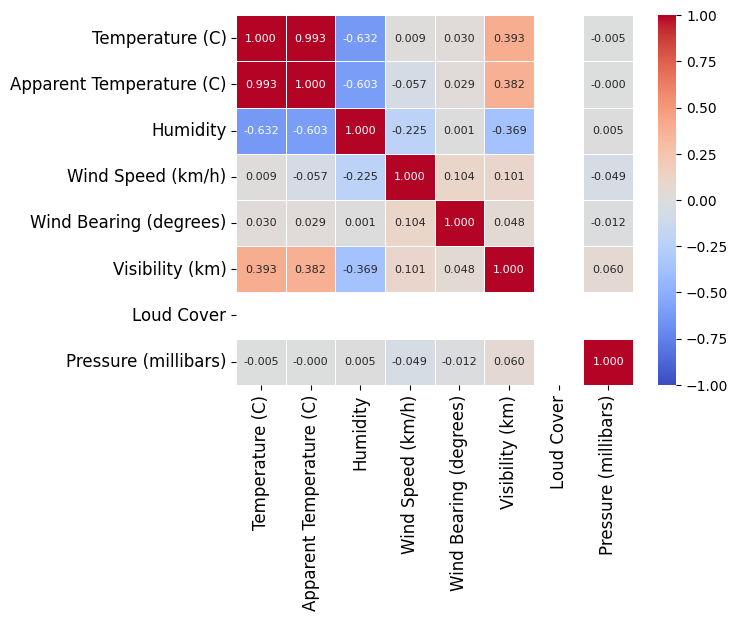

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', linewidths=0.5, annot_kws={"size": 8}, fmt='.3f',
            yticklabels=corr_matrix.columns, vmin=-1, vmax=1)  # Set vmin and vmax

# Adjust font size of annotations
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# sn.heatmap(corr_matrix, annot=True)
# plt.show()


In [ ]:
plt.hist(df, bins=10, edgecolor = 'black')

(array([ 1288.,     0.,     0.,     0.,     0.,     0.,     0.,     0.,
            0., 95165.]),
 array([   0.   ,  104.638,  209.276,  313.914,  418.552,  523.19 ,
         627.828,  732.466,  837.104,  941.742, 1046.38 ]),
 <BarContainer object of 10 artists>)

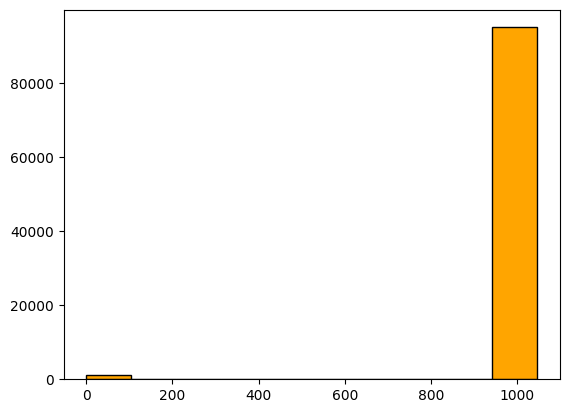

In [ ]:
'Temperature (C)', 'Apparent Temperature (C)', 'Humidity', 'Wind Speed (km/h)', 'Wind Bearing (degrees)', 'Visibility (km)', 'Loud Cover', 'Pressure (millibars)'

X= df['Pressure (millibars)'].values
# X
plt.hist(X, color = 'orange', edgecolor = 'black')
# plt.scatter(X[:, 0], X[:, 1], y)

#LS

In [55]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

'Temperature (C)', 'Apparent Temperature (C)', 'Humidity', 'Wind Speed (km/h)', 'Wind Bearing (degrees)', 'Visibility (km)', 'Loud Cover', 'Pressure (millibars)'

data =pd.DataFrame(df[['Apparent Temperature (C)']])
target=pd.DataFrame(df[['Temperature (C)']])


In [56]:
x=data
y=target

In [57]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=64)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((77162, 1), (19291, 1), (77162, 1), (19291, 1))

In [63]:
#Normalizing Data
from sklearn.preprocessing import MinMaxScaler
# Create a MinMaxScaler instance
scaler = MinMaxScaler()

# Fit the scaler on the training data and transform it
x_train_normalized = scaler.fit_transform(x_train)
y_train_normalized = scaler.fit_transform(y_train)
# Transform the test data using the same scaler
x_test_normalized = scaler.fit_transform(x_test)
y_test_normalized = scaler.fit_transform(y_test)


In [64]:
model=LinearRegression()
model.fit(x_train_normalized, y_train_normalized)
y_pred=model.predict(x_test_normalized)

mse= mean_squared_error(y_test_normalized, y_pred)
# mse = np.mean((y - model.predict(x))**2)

print("mean squared error : ", mse)

mean squared error :  0.0011834143036205066


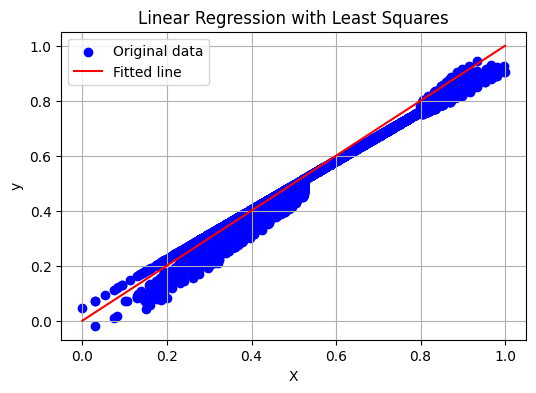

In [65]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))#
plt.scatter(y_test_normalized , y_pred, color='blue', label='Original data')
plt.plot([y_test_normalized.min(), y_test_normalized.max()], [y_test_normalized.min(), y_test_normalized.max()], color='red', label='Fitted line')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Linear Regression with Least Squares')
plt.legend()
plt.grid(True)
plt.show()

Mean Squared Error: 1.3368092328808803


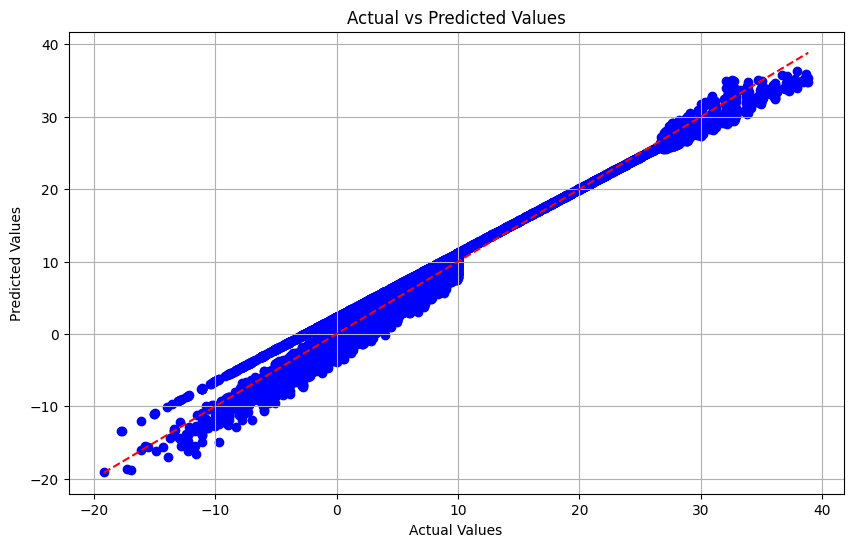

In [ ]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# Load the Boston Housing dataset
data =pd.DataFrame(df[['Apparent Temperature (C)']])
target=pd.DataFrame(df[['Temperature (C)']])


# Split the dataset into features (X) and target variable (y)
X = data
y = target

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and fit the linear regression model using least squares
model = LinearRegressionLS()
model.fit(X_train, y_train)

# Make predictions on the testing set
y_pred = model.predict(X_test)

# Calculate Mean Squared Error
mse = mean_squared_error(y_test, y_pred)
print("Mean Squared Error:", mse)

# Plot actual vs predicted values
plt.figure(figsize=(10, 6))
plt.scatter(y_test, y_pred, color='blue' ,label='Predicted Values')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--',label='Predicted Values')
plt.xlabel('Actual Values')
plt.ylabel('Predicted Values')
plt.title('Actual vs Predicted Values')
plt.grid(True)
plt.show()


#RLS

In [44]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

'Temperature (C)', 'Apparent Temperature (C)', 'Humidity', 'Wind Speed (km/h)', 'Wind Bearing (degrees)', 'Visibility (km)', 'Loud Cover', 'Pressure (millibars)'

data =pd.DataFrame(df[['Apparent Temperature (C)']])
target=pd.DataFrame(df[['Temperature (C)']])
x=data
y=target
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=64)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((77162, 1), (19291, 1), (77162, 1), (19291, 1))

In [48]:
#Normalizing Data
from sklearn.preprocessing import MinMaxScaler
# Create a MinMaxScaler instance
scaler = MinMaxScaler()

# Fit the scaler on the training data and transform it
X_train_normalized = scaler.fit_transform(x_train)
y_train_normalized = scaler.fit_transform(y_train)
# Transform the test data using the same scaler
X_test_normalized = scaler.fit_transform(x_test)
y_test_normalized = scaler.fit_transform(y_test)


Mean Squared Error: 0.0003997980721860095


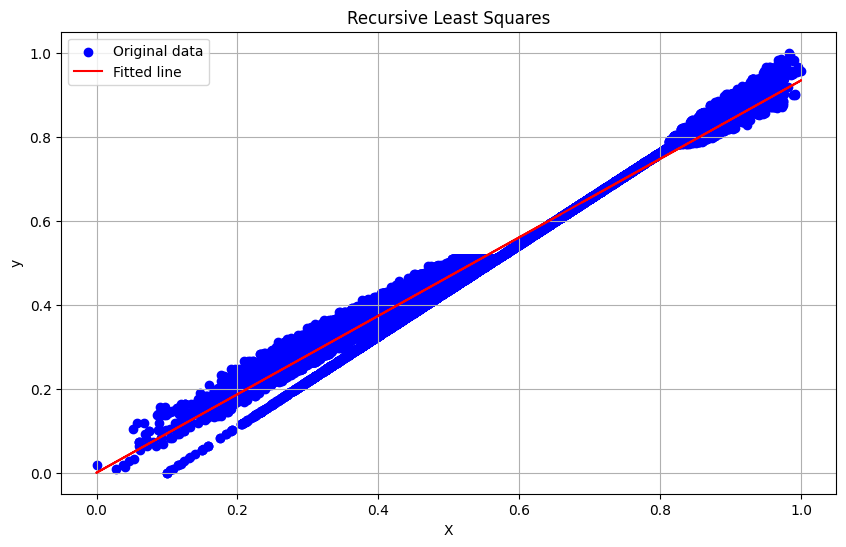

In [62]:
import numpy as np
import matplotlib.pyplot as plt

class RecursiveLeastSquares:
    def __init__(self, n_features, forgetting_factor=0.99):
        self.n_features = n_features
        self.forgetting_factor = forgetting_factor
        self.theta = np.zeros((n_features, 1))  # Initialize model parameters
        self.P = np.eye(n_features)  # Initialize covariance matrix

    def fit(self, X, y):
        errors = []
        for i in range(len(X)):
            x_i = X[i].reshape(-1, 1)
            y_i = y[i]

            # Predict
            y_pred = np.dot(x_i.T, self.theta)

            # Update
            error = y_i - y_pred
            errors.append(error)
            K = np.dot(self.P, x_i) / (self.forgetting_factor + np.dot(np.dot(x_i.T, self.P), x_i))
            self.theta = self.theta + np.dot(K, error)
            self.P = (1 / self.forgetting_factor) * (self.P - np.dot(K, np.dot(x_i.T, self.P)))

        return errors

    def predict(self, X):
        return np.dot(X, self.theta)

if __name__ == "__main__":

    # Initialize and fit the RLS model
    rls = RecursiveLeastSquares(n_features=1)
    errors = rls.fit(X_train_normalized, y_train_normalized)

    # Make predictions
    y_pred = rls.predict(X_train_normalized)

    # Calculate Mean Squared Error
    mse = np.mean(np.array(errors)**2)
    print("Mean Squared Error:", mse)


    # Plot the results
    plt.figure(figsize=(10, 6))
    plt.scatter(X_train_normalized, y_train_normalized, color='blue', label='Original data')
    plt.plot(X_train_normalized, y_pred, color='red', label='Fitted line')
    plt.xlabel('X')
    plt.ylabel('y')
    plt.title('Recursive Least Squares')
    plt.legend()
    plt.grid(True)
    plt.show()



#WLS

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

'Temperature (C)', 'Apparent Temperature (C)', 'Humidity', 'Wind Speed (km/h)', 'Wind Bearing (degrees)', 'Visibility (km)', 'Loud Cover', 'Pressure (millibars)'

data =pd.DataFrame(df[['Apparent Temperature (C)']])
target=pd.DataFrame(df[['Temperature (C)']])
x=data
y=target
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=64)
x_train.shape, x_test.shape, y_train.shape, y_test.shape

((77162, 1), (19291, 1), (77162, 1), (19291, 1))

In [6]:
#Normalizing Data
from sklearn.preprocessing import MinMaxScaler
# Create a MinMaxScaler instance
scaler = MinMaxScaler()

# Fit the scaler on the training data and transform it
X_train_normalized = scaler.fit_transform(x_train)
y_train_normalized = scaler.fit_transform(y_train)
# Transform the test data using the same scaler
X_test_normalized = scaler.fit_transform(x_test)
y_test_normalized = scaler.fit_transform(y_test)


In [7]:
import numpy as np
import statsmodels.api as sm

X = X_train_normalized
y = y_train_normalized

error_variance = 2  # Modify this value based on your estimation

# Calculate weights based on the estimated variance
weights = 1 / error_variance

# Fit the weighted least squares model
X_with_intercept = sm.add_constant(X)  # Add intercept term
model = sm.WLS(y, X_with_intercept, weights=weights)
result = model.fit()

# Print the model summary
print(result.summary())


                            WLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.985
Model:                            WLS   Adj. R-squared:                  0.985
Method:                 Least Squares   F-statistic:                 5.172e+06
Date:                Sat, 06 Apr 2024   Prob (F-statistic):               0.00
Time:                        13:08:05   Log-Likelihood:             1.9649e+05
No. Observations:               77162   AIC:                        -3.930e+05
Df Residuals:                   77160   BIC:                        -3.929e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0185      0.000    -72.435      0.0